Loading forecast data from Task 3...
Forecast data loaded successfully!

Fetching historical data for SPY and BND...


[*********************100%***********************]  3 of 3 completed


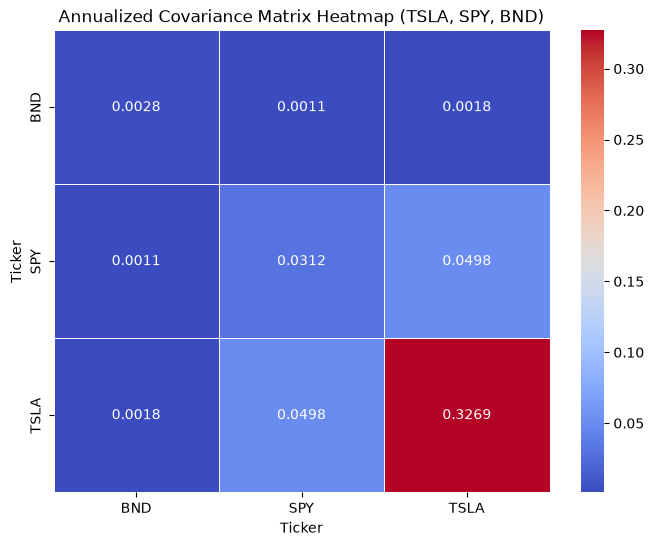


Preparing Expected Returns...
--- Annualized Expected Returns ---
Ticker
BND     0.0200
SPY     0.1443
TSLA   -0.6722
dtype: float64


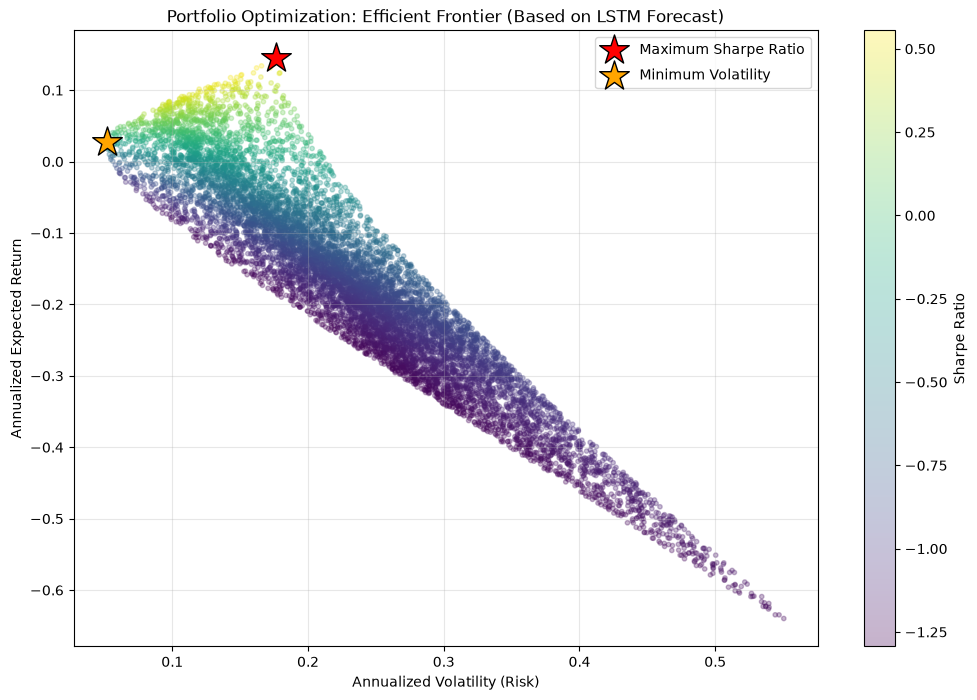


=== MAX SHARPE PORTFOLIO (RECOMMENDED) ===
Weights:
  BND: 0.00%
  SPY: 100.00%
  TSLA: 0.00%
Expected Annual Return: 14.43%
Expected Volatility: 17.65%
Sharpe Ratio: 0.58


In [6]:
# Cell 1: Load Forecast Data & Fetch Historical Data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
import requests
import seaborn as sns
import scipy.optimize as sco

print("Loading forecast data from Task 3...")
load_dir = './data/processed/'
# 1. Load the test data and future forecast that we saved in Task 3
test_data = pd.read_csv(f'{load_dir}tsla_test_data.csv', index_col=0, parse_dates=True).squeeze()
future_forecast_series = pd.read_csv(f'{load_dir}tsla_future_forecast.csv', index_col=0, parse_dates=True).squeeze()
print("Forecast data loaded successfully!")

print("\nFetching historical data for SPY and BND...")
# 2. Fetch SPY and BND using our browser spoofing trick
session = requests.Session()
session.headers['User-agent'] = 'Mozilla/5.0'
tickers = ['TSLA', 'SPY', 'BND']
data = yf.download(tickers, start='2015-01-01', end='2026-06-30', session=session)

# Clean up index and extract Close prices
data.index = pd.to_datetime(data.index).tz_localize(None)
if isinstance(data.columns, pd.MultiIndex):
    close_prices = data['Close'].copy()
else:
    close_prices = data.copy()

# =====================================================================

# Cell 2: Calculate Covariance Matrix & Heatmap
# Calculate Daily Returns & Covariance Matrix
daily_returns = close_prices.pct_change().dropna()
cov_matrix_annual = daily_returns.cov() * 252 # Annualized

# Plot Covariance Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cov_matrix_annual, annot=True, cmap='coolwarm', fmt=".4f", linewidths=0.5)
plt.title("Annualized Covariance Matrix Heatmap (TSLA, SPY, BND)")
plt.show()

# =====================================================================

# Cell 3: Prepare Expected Returns & Generate Efficient Frontier
print("\nPreparing Expected Returns...")
# SPY and BND use historical average annualized returns
exp_returns = daily_returns.mean() * 252 

# TSLA uses the forecasted return from our LSTM model dynamically!
initial_tsla_price = test_data.iloc[-1]
final_tsla_price = future_forecast_series.iloc[-1]
forecast_days = len(future_forecast_series)

# Calculate annualized return based on the 6-month forecast trajectory
tsla_forecast_ann_return = ((final_tsla_price / initial_tsla_price) ** (252 / forecast_days)) - 1
exp_returns['TSLA'] = tsla_forecast_ann_return

print("--- Annualized Expected Returns ---")
print(exp_returns.round(4))

# --- Portfolio Optimization Setup ---
num_assets = len(tickers)
risk_free_rate = 0.042 # Approx 4.2% current risk-free rate

def portfolio_performance(weights, exp_returns, cov_matrix):
    returns = np.sum(exp_returns * weights)
    std_dev = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
    return std_dev, returns

def neg_sharpe_ratio(weights, exp_returns, cov_matrix, rf_rate):
    p_std, p_ret = portfolio_performance(weights, exp_returns, cov_matrix)
    return -(p_ret - rf_rate) / p_std

# Constraints: Weights must sum to 1, and bounds are 0 to 1 (no short selling)
constraints = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})
bounds = tuple((0, 1) for _ in range(num_assets))
init_guess = num_assets * [1. / num_assets,]

# 1. Optimize for Maximum Sharpe Ratio (Tangency Portfolio)
opt_sharpe = sco.minimize(neg_sharpe_ratio, init_guess, args=(exp_returns, cov_matrix_annual, risk_free_rate),
                          method='SLSQP', bounds=bounds, constraints=constraints)

# 2. Optimize for Minimum Volatility
opt_min_vol = sco.minimize(lambda w: portfolio_performance(w, exp_returns, cov_matrix_annual)[0], 
                           init_guess, method='SLSQP', bounds=bounds, constraints=constraints)

# --- Simulate 10,000 Random Portfolios for the Cloud Plot ---
num_portfolios = 10000
results = np.zeros((3, num_portfolios))
for i in range(num_portfolios):
    weights = np.random.random(num_assets)
    weights /= np.sum(weights)
    p_std, p_ret = portfolio_performance(weights, exp_returns, cov_matrix_annual)
    results[0,i] = p_std
    results[1,i] = p_ret
    results[2,i] = (p_ret - risk_free_rate) / p_std # Sharpe Ratio

# --- Plot the Efficient Frontier ---
plt.figure(figsize=(12, 8))
scatter = plt.scatter(results[0,:], results[1,:], c=results[2,:], cmap='viridis', marker='o', s=10, alpha=0.3)
plt.colorbar(scatter, label='Sharpe Ratio')

# Mark Max Sharpe Portfolio
max_sharpe_std, max_sharpe_ret = portfolio_performance(opt_sharpe.x, exp_returns, cov_matrix_annual)
plt.scatter(max_sharpe_std, max_sharpe_ret, marker='*', color='red', s=500, edgecolor='black', label='Maximum Sharpe Ratio')

# Mark Min Volatility Portfolio
min_vol_std, min_vol_ret = portfolio_performance(opt_min_vol.x, exp_returns, cov_matrix_annual)
plt.scatter(min_vol_std, min_vol_ret, marker='*', color='orange', s=500, edgecolor='black', label='Minimum Volatility')

plt.title('Portfolio Optimization: Efficient Frontier (Based on LSTM Forecast)')
plt.xlabel('Annualized Volatility (Risk)')
plt.ylabel('Annualized Expected Return')
plt.legend(labelspacing=0.8)
plt.grid(True, alpha=0.3)
plt.show()

# Print Final Recommendations
tickers_list = exp_returns.index.tolist()
print("\n=== MAX SHARPE PORTFOLIO (RECOMMENDED) ===")
print("Weights:")
for tic, w in zip(tickers_list, opt_sharpe.x):
    print(f"  {tic}: {w*100:.2f}%")
print(f"Expected Annual Return: {max_sharpe_ret*100:.2f}%")
print(f"Expected Volatility: {max_sharpe_std*100:.2f}%")
print(f"Sharpe Ratio: {(max_sharpe_ret - risk_free_rate) / max_sharpe_std:.2f}")